# Privathaushalte nach Haushaltsform und Stadtquartier

### Kurzbeschreibung
Anzahl Privathaushalte sowie die wirtschaftliche Wohnbevölkerung der Stadt Zürich in Privathaushalten nach Haushaltsform, Statistischem Stadtquartier und Jahr.

Datum: 19.08.2024


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_hh_haushaltsform_quartier_seit2013_od3805

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_hh_haushaltsform_quartier_seit2013_od3805


### Importiere die notwendigen Packages

In [47]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [48]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [49]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [50]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [51]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [52]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [53]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [54]:
package_name = "bev_hh_haushaltsform_quartier_seit2013_od3805"

In [55]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV380OD3805"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_hh_haushaltsform_quartier_seit2013_od3805/download/BEV380OD3805.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_hh_haushaltsform_quartier_seit2013_od3805 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_hh_haushaltsform_quartier_seit2013_od3805 

data_source: web


In [56]:
data2betested.head(2).T

,0,1
StichtagDatJahr,2014-01-01 00:00:00,2014-01-01 00:00:00
QuarSort,11,11
QuarLang,Rathaus,Rathaus
KreisSort,1,1
KreisLang,Kreis 1,Kreis 1
HHtypSort,1,4
HHtypLang,Einpersonenhaushalt,Zweipersonenhaushalt
AnzHH,1133,278
AnzBestWir,1133,556


Berechne weitere Attribute falls notwendig

In [57]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
QuarSort                        int64
QuarLang                       object
KreisSort                       int64
KreisLang                      object
HHtypSort                       int64
HHtypLang                      object
AnzHH                           int64
AnzBestWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [58]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 2014 und ein Maximumjahr von 2024


### Einfache Datentests

In [59]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 4357 entries, 4356 to 0
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      4357 non-null   datetime64[ns]
 1   QuarSort             4357 non-null   int64         
 2   QuarLang             4357 non-null   object        
 3   KreisSort            4357 non-null   int64         
 4   KreisLang            4357 non-null   object        
 5   HHtypSort            4357 non-null   int64         
 6   HHtypLang            4357 non-null   object        
 7   AnzHH                4357 non-null   int64         
 8   AnzBestWir           4357 non-null   int64         
 9   StichtagDatJahr_str  4357 non-null   object        
 10  Jahr                 4357 non-null   datetime64[ns]
 11  Jahr_nbr             4357 non-null   int32         
dtypes: datetime64[ns](2), int32(1), int64(5), object(4)
memory usage: 1.4 MB


In [60]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 4,357 rows (observations) and 12 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [61]:
data2betested.describe()

,StichtagDatJahr,QuarSort,KreisSort,HHtypSort,AnzHH,AnzBestWir,Jahr,Jahr_nbr
count,4357,4357,4357,4357,4357,4357,4357,4357
mean,2019-01-07 09:04:40.100986880,65,6,8,519,1043,2019-01-07 09:04:40.100986880,2019
min,2014-01-01 00:00:00,11,1,1,1,2,2014-01-01 00:00:00,2014
25%,2016-01-01 00:00:00,33,3,5,27,84,2016-01-01 00:00:00,2016
50%,2019-01-01 00:00:00,71,7,8,134,466,2019-01-01 00:00:00,2019
75%,2022-01-01 00:00:00,92,9,12,554,1329,2022-01-01 00:00:00,2022
max,2024-01-01 00:00:00,123,12,15,8158,9421,2024-01-01 00:00:00,2024
std,NaN,36,4,4,953,1475,NaN,3


Welches sind die Quartiere ohne Werte bei BEW?

In [62]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,QuarSort,QuarLang,KreisSort,KreisLang,HHtypSort,HHtypLang,AnzHH,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [63]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [64]:
data2betested.index.year.unique()

Index([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [65]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [66]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,QuarSort,KreisSort,HHtypSort,AnzHH,AnzBestWir,Jahr_nbr
count,"4,357","4,357","4,357","4,357","4,357","4,357"
mean,65,6,8,519,"1,043","2,019"
std,36,4,4,953,"1,475",3
min,11,1,1,1,2,"2,014"
25%,33,3,5,27,84,"2,016"
50%,71,7,8,134,466,"2,019"
75%,92,9,12,554,"1,329","2,022"
max,123,12,15,"8,158","9,421","2,024"


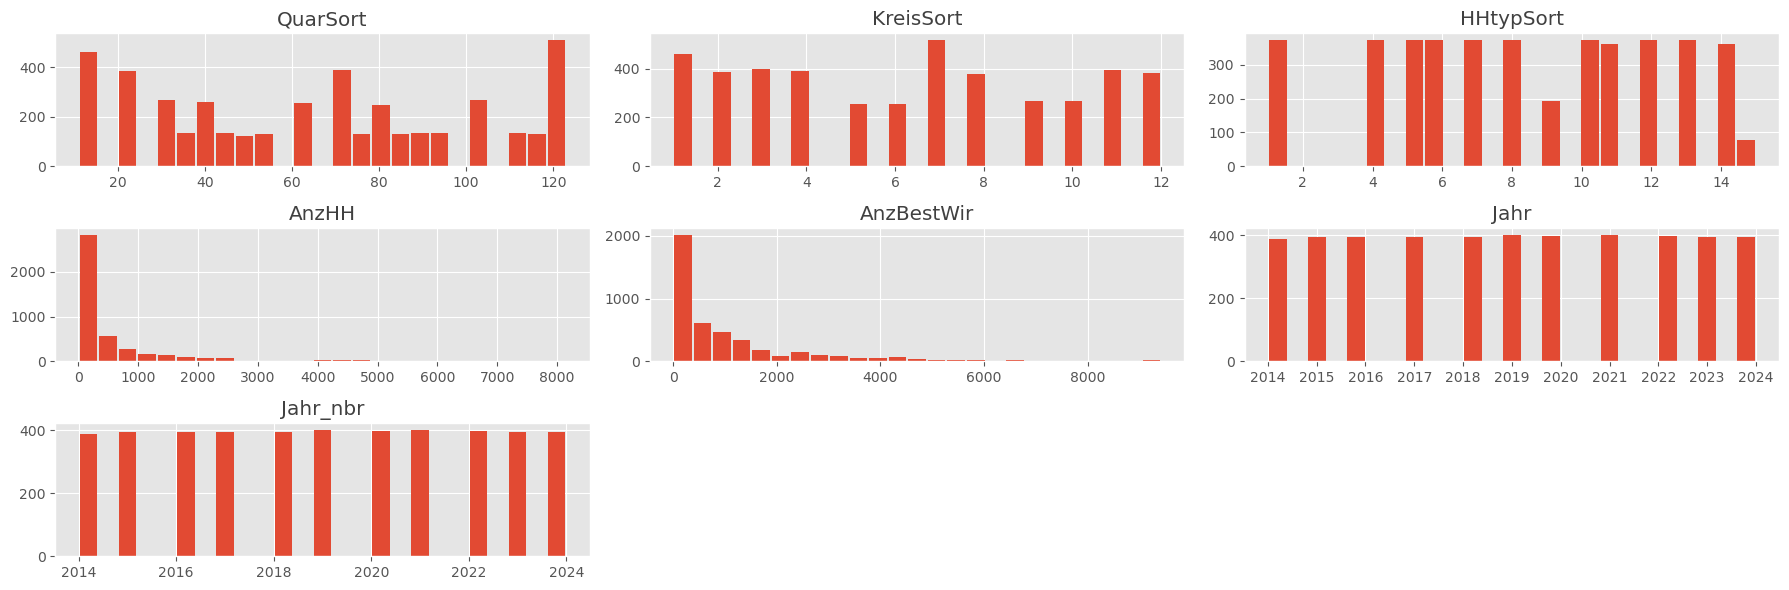

In [67]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [68]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,QuarSort,QuarLang,KreisSort,KreisLang,HHtypSort,HHtypLang,AnzHH,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,


### Nullwerte und Missings?

In [69]:
data2betested.isnull().sum()

QuarSort               0
QuarLang               0
KreisSort              0
KreisLang              0
HHtypSort              0
HHtypLang              0
AnzHH                  0
AnzBestWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_nbr               0
dtype: int64

In [70]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [71]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum'), sum_AnzHH=('AnzHH', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,sum_AnzBestWir,sum_AnzHH
0,2024-01-01,2024,433907,215323
1,2023-01-01,2023,432220,215026
2,2022-01-01,2022,427347,213149


In [72]:
agg_hhtyp = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'HHtypSort','HHtypLang' ]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum'), sum_AnzHH=('AnzHH', 'sum')) \
    .sort_values(['Jahr','HHtypSort'], ascending=[False, False]) 
agg_hhtyp.reset_index().head(13)

,Jahr,HHtypSort,HHtypLang,sum_AnzBestWir,sum_AnzHH
0,2024-01-01,15,Familien-Verbund,13,3
1,2024-01-01,14,Generationenhaushalt,4679,901
2,2024-01-01,13,Wohngemeinschaft mit Kind(ern),15612,3273
3,2024-01-01,12,Wohngemeinschaft ohne Kinder,32550,9467
4,2024-01-01,11,Patchwork-Haushalt,3409,1027
5,2024-01-01,10,Paar mit Kind(ern),24825,6991
6,2024-01-01,9,Eingetragenes Paar mit Kind(ern),80,23
7,2024-01-01,8,Ehepaar mit Kind(ern),115951,30382
8,2024-01-01,7,Ein-Elternhaushalt,26126,10567
9,2024-01-01,6,Eingetragenes Paar ohne Kinder,930,465


In [73]:
agg_quar_kr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['QuarSort', 'QuarLang', 'KreisSort', 'KreisLang',]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum'), sum_AnzHH=('AnzHH', 'sum')) \
    .sort_values('QuarSort', ascending=False) 
agg_quar_kr.reset_index().head(10)

,QuarSort,QuarLang,KreisSort,KreisLang,sum_AnzBestWir,sum_AnzHH
0,123,Hirzenbach,12,Kreis 12,135268,62068
1,122,Schwamendingen-Mitte,12,Kreis 12,121285,61217
2,121,Saatlen,12,Kreis 12,93400,36744
3,119,Seebach,11,Kreis 11,277881,131854
4,115,Oerlikon,11,Kreis 11,240011,122435
5,111,Affoltern,11,Kreis 11,281386,125915
6,102,Wipkingen,10,Kreis 10,175010,93931
7,101,Höngg,10,Kreis 10,249066,121511
8,92,Altstetten,9,Kreis 9,362480,182162
9,91,Albisrieden,9,Kreis 9,234100,116917


In [74]:
data2betested.columns

Index(['QuarSort', 'QuarLang', 'KreisSort', 'KreisLang', 'HHtypSort', 'HHtypLang', 'AnzHH',
       'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

### Visualisierungen nach Zeitausschnitten

#### Entwicklung Wochenaufenthaltender nach Altersgruppe

In [75]:
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'HHtypSort','HHtypLang' ]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum'), sum_AnzHH=('AnzHH', 'sum')) \
    .sort_values(['Jahr','HHtypSort'], ascending=[True, False]) 
myAgg1.reset_index().head(3)

,Jahr,HHtypSort,HHtypLang,sum_AnzBestWir,sum_AnzHH
0,2014-01-01,15,Familien-Verbund,30,7
1,2014-01-01,14,Generationenhaushalt,5275,967
2,2014-01-01,13,Wohngemeinschaft mit Kind(ern),22024,4458


In [76]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('HHtypSort', ascending=True)
    ,x = 'Jahr:T'
    ,y = 'sum_AnzBestWir' #'sum_AnzHH:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "HHtypLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Wohnbevölkerung nach Haushaltstyp, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung der Haushalte nach Typ

In [77]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('HHtypSort', ascending=True)
    ,x = 'Jahr:T'
    ,y = 'sum_AnzHH' #'sum_AnzHH:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "HHtypLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Haushalte nach Haushaltstyp, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

#### Faced Grids

In [78]:
data2betested.columns

Index(['QuarSort', 'QuarLang', 'KreisSort', 'KreisLang', 'HHtypSort', 'HHtypLang', 'AnzHH',
       'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [79]:
myFG = data2betested

In [80]:
myFG.columns

Index(['QuarSort', 'QuarLang', 'KreisSort', 'KreisLang', 'HHtypSort', 'HHtypLang', 'AnzHH',
       'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

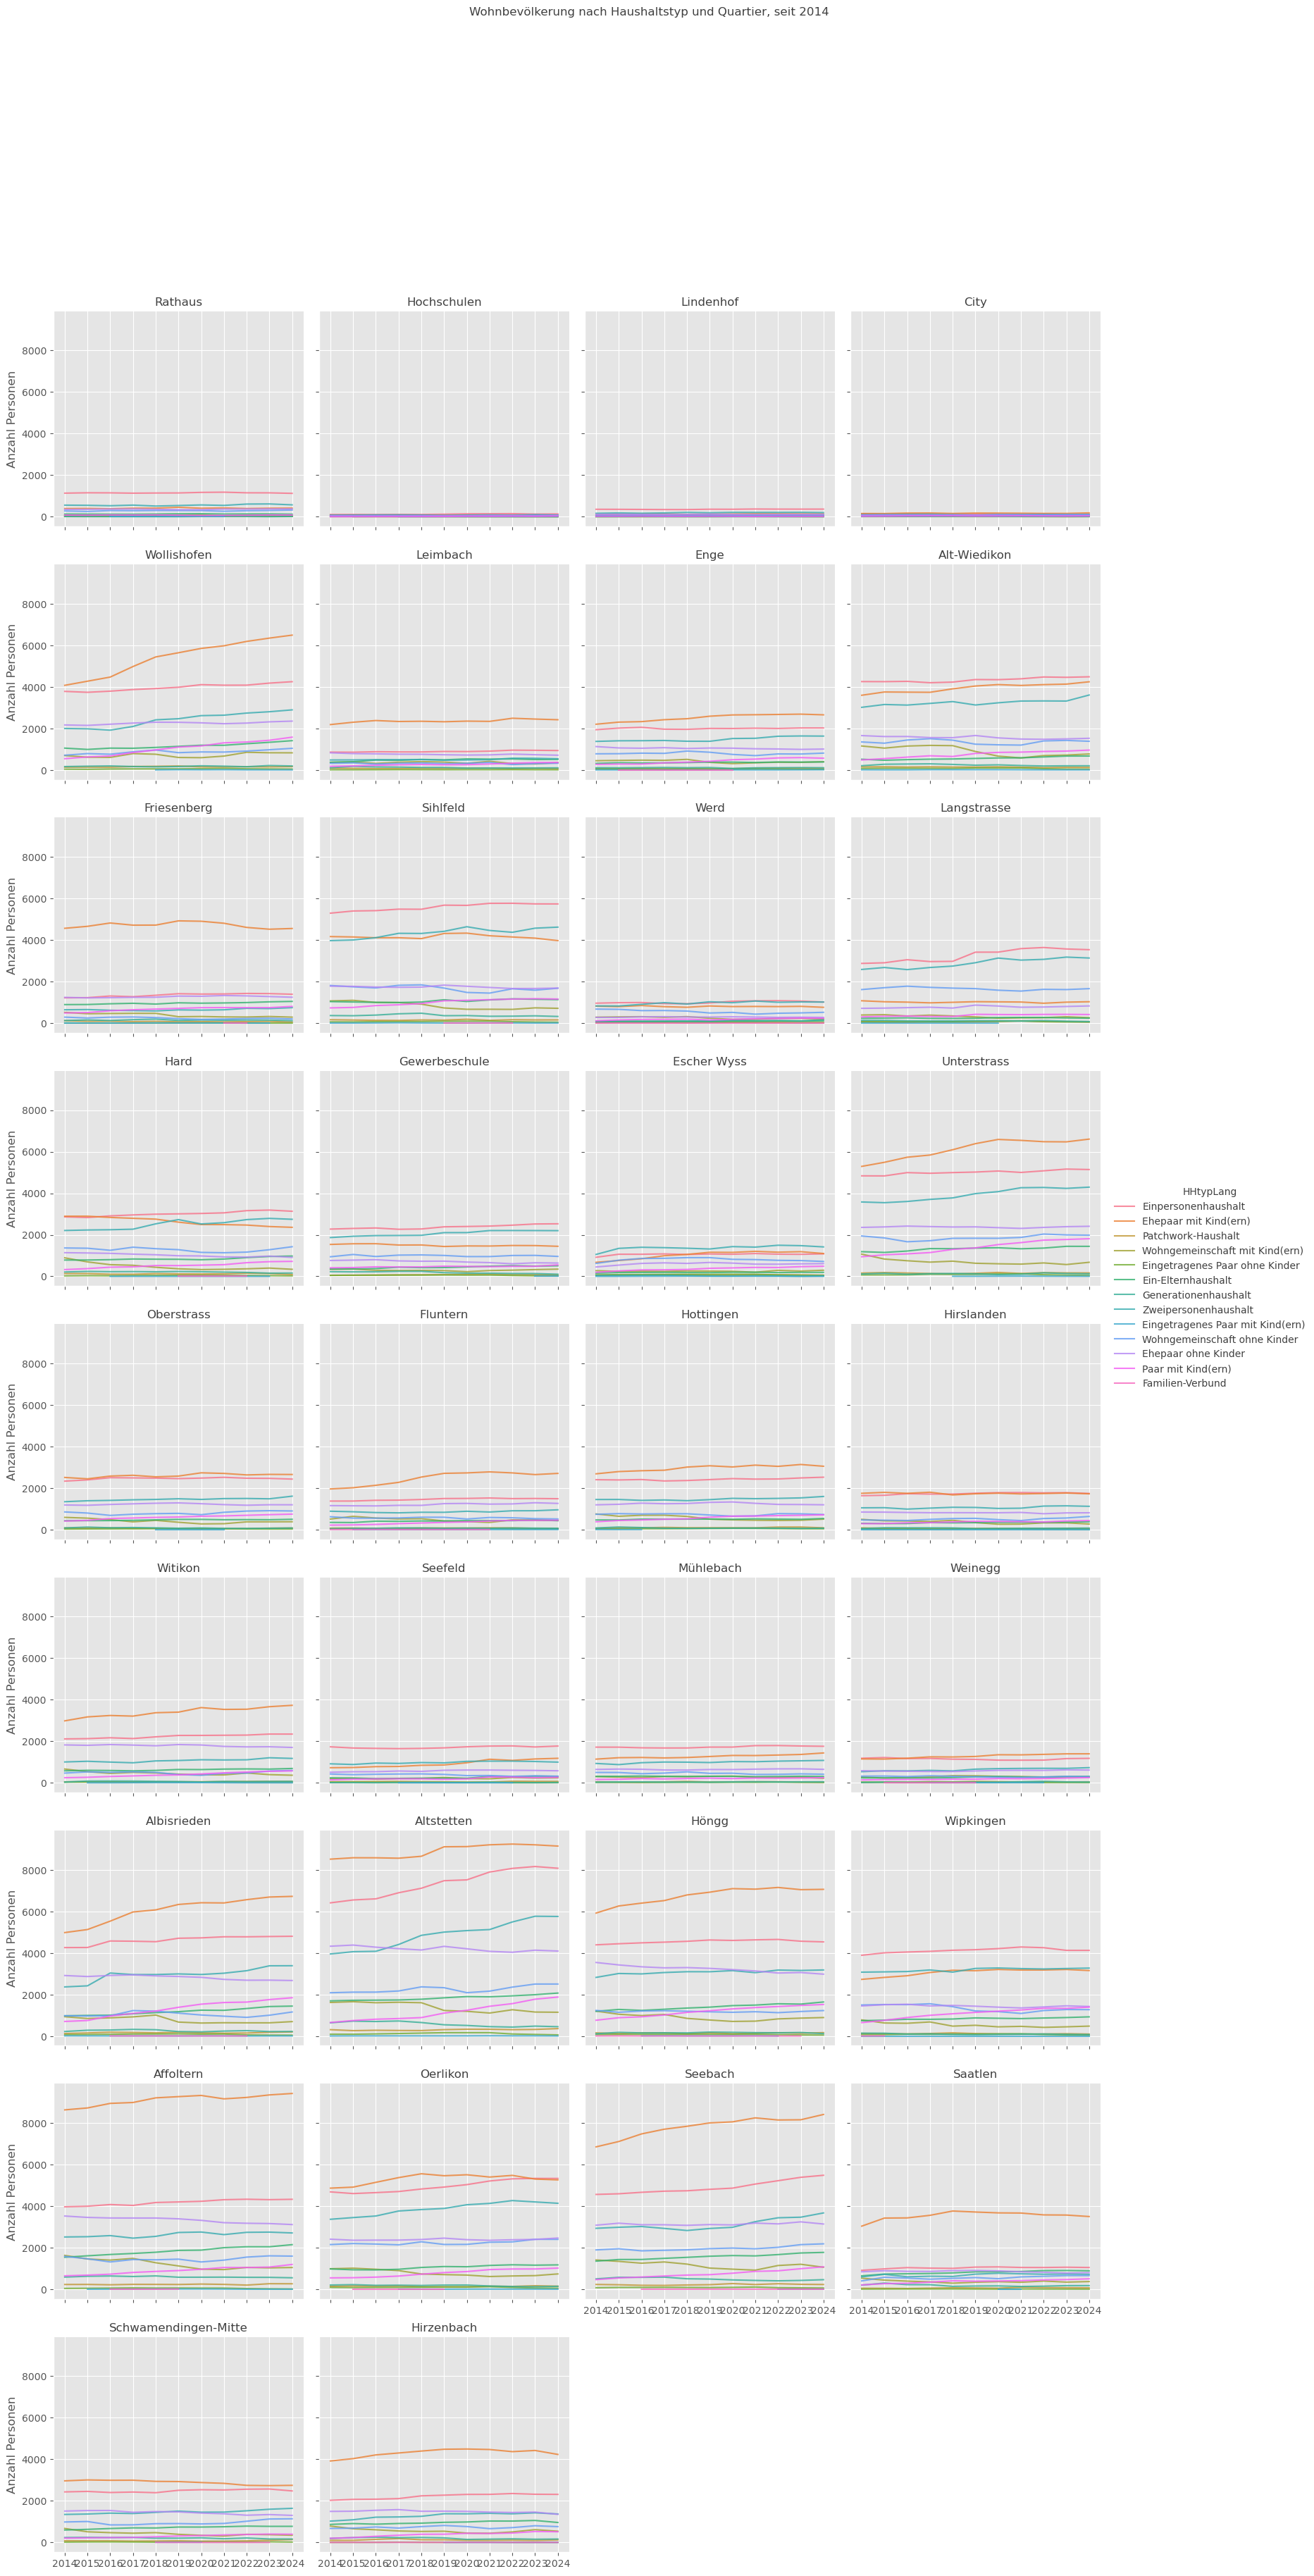

In [81]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('QuarSort', ascending=True)
    ,col = "QuarLang"
    ,hue = "HHtypLang"
    ,col_wrap = 4
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzBestWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Wohnbevölkerung nach Haushaltstyp und Quartier, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

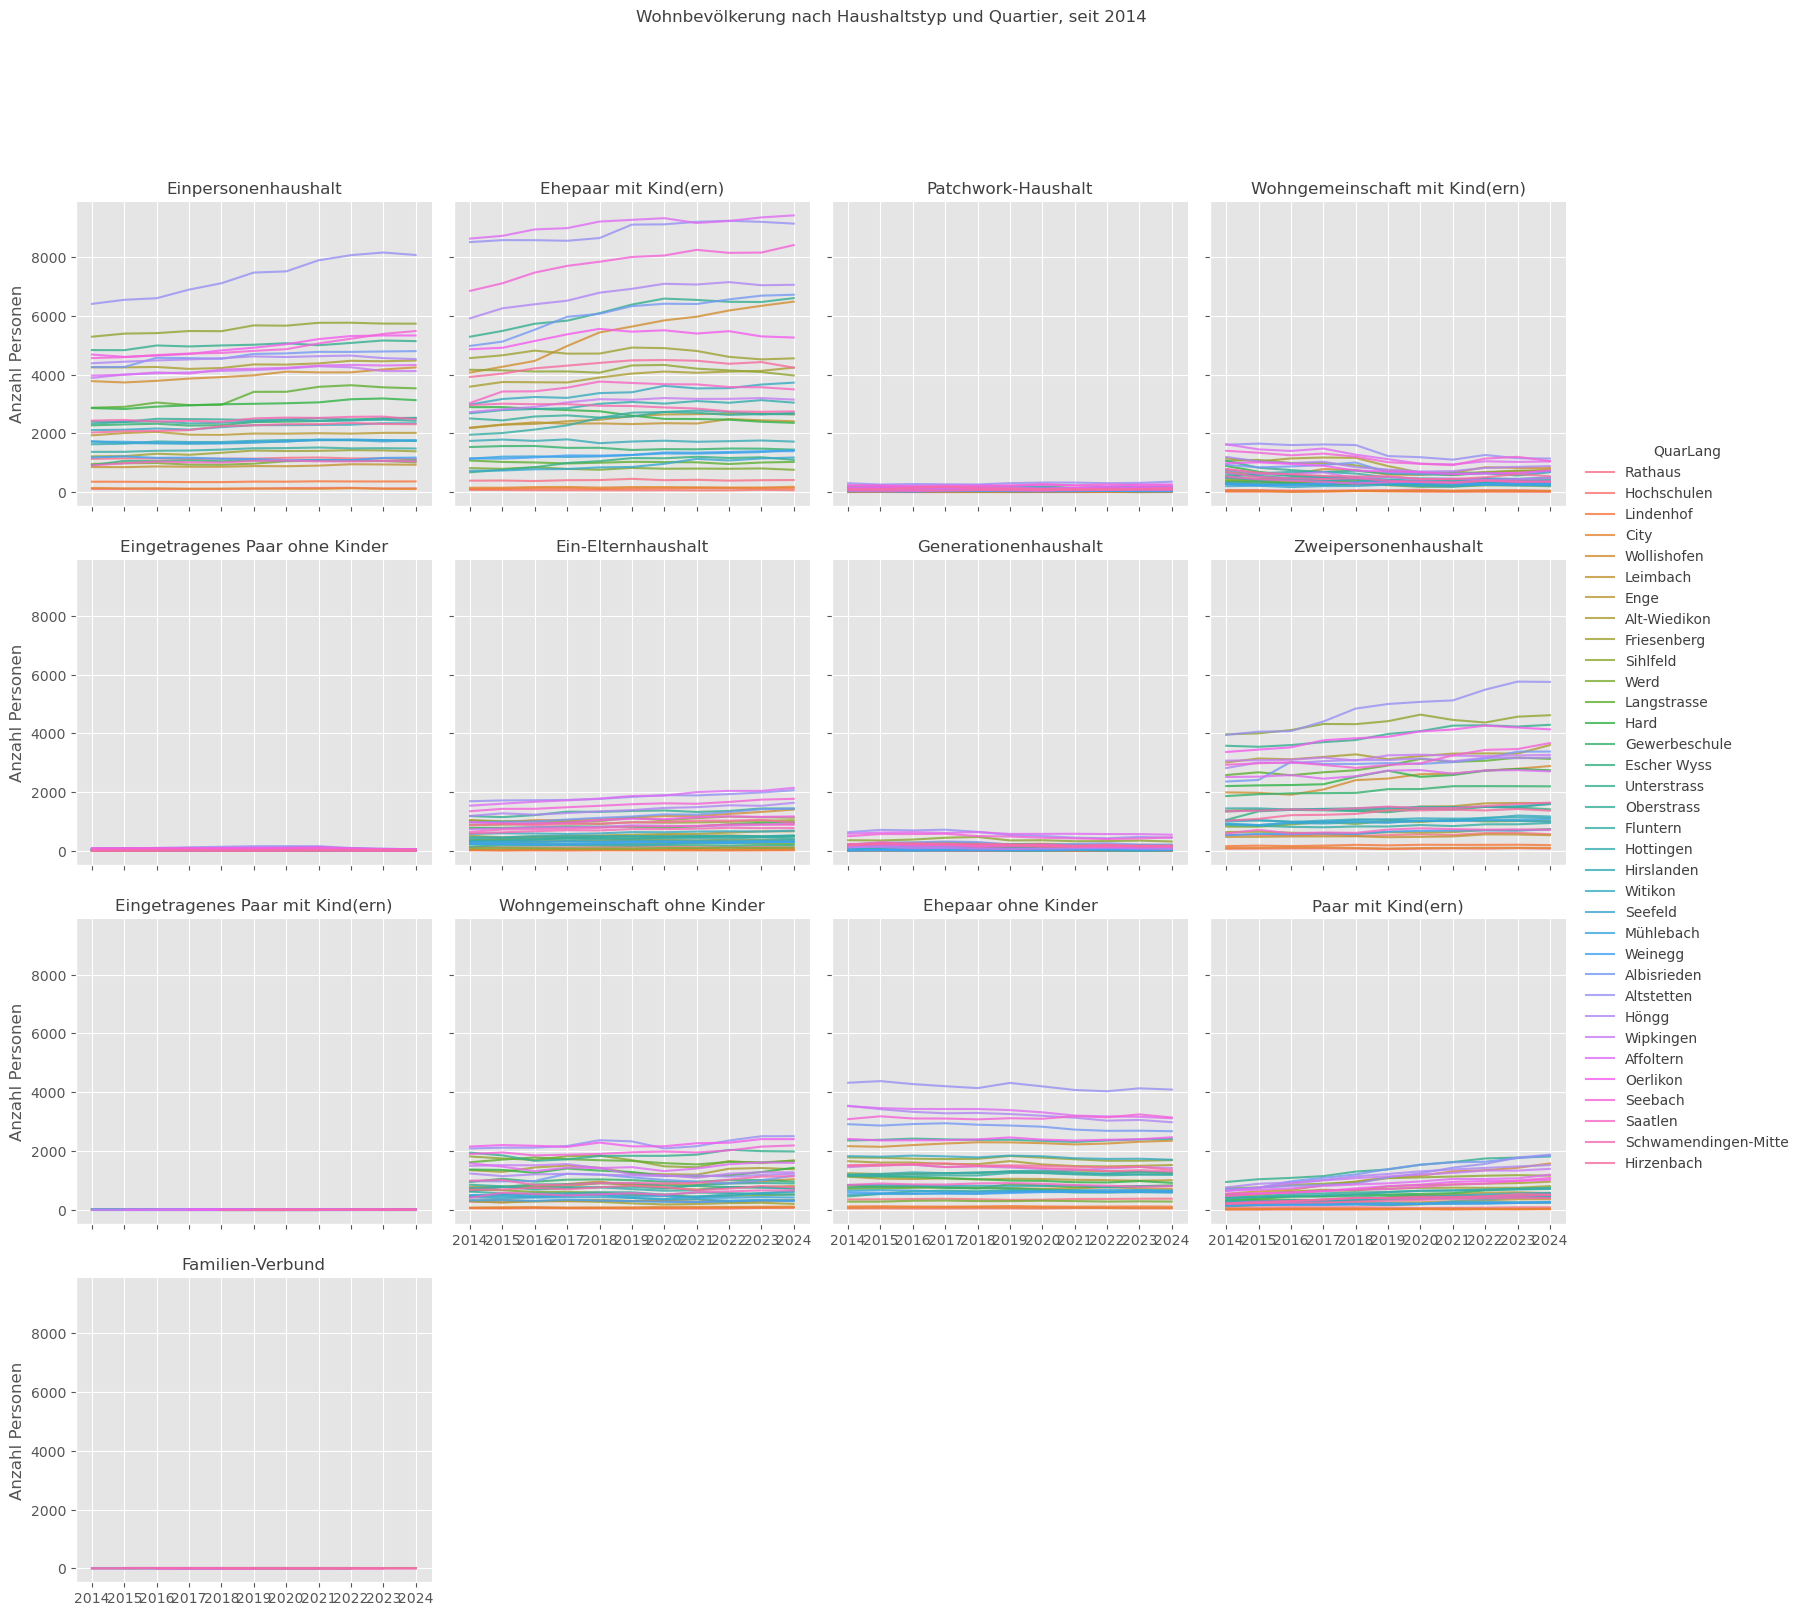

In [82]:
faced_grid2 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('QuarSort', ascending=True)
    ,col = "HHtypLang"
    ,hue = "QuarLang"
    ,col_wrap = 4
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzBestWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Wohnbevölkerung nach Haushaltstyp und Quartier, seit "+str(int(data2betested.index.year.min()))
)
faced_grid2

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [83]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [84]:
# Extrahiere die Top-Fahrzeugmarken
attr2becolored = data2betested['HHtypLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(attr2becolored):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Einpersonenhaushalt': '#0017BF', 'Ehepaar ohne Kinder': '#0072D7', 'Generationenhaushalt': '#00A5D2', 'Ein-Elternhaushalt': '#5E359A', 'Eingetragenes Paar ohne Kinder': '#BA0062', 'Ehepaar mit Kind(ern)': '#DA5563', 'Paar mit Kind(ern)': '#00615D', 'Patchwork-Haushalt': '#00770F', 'Wohngemeinschaft ohne Kinder': '#7BA600', 'Zweipersonenhaushalt': '#7B4100', 'Wohngemeinschaft mit Kind(ern)': '#DC5500', 'Eingetragenes Paar mit Kind(ern)': '#DA9C00', 'Familien-Verbund': '#5D4BFE'}


##### Wohnbevölkerung nach Haushaltstyp und Quartier

In [85]:
data2betested.columns

Index(['QuarSort', 'QuarLang', 'KreisSort', 'KreisLang', 'HHtypSort', 'HHtypLang', 'AnzHH',
       'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [86]:
myTM = data2betested.loc[data_max_date].reset_index() \
    .groupby(['StichtagDatJahr', 'QuarLang', 'KreisLang', 'HHtypLang']) \
    .agg(AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AnzBestWir', ascending=False) 

myTM.reset_index().head(2)

,StichtagDatJahr,QuarLang,KreisLang,HHtypLang,AnzBestWir
0,2024-01-01,Affoltern,Kreis 11,Ehepaar mit Kind(ern),9421
1,2024-01-01,Altstetten,Kreis 9,Ehepaar mit Kind(ern),9141


In [87]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['KreisLang','QuarLang', 'HHtypLang', ]
    ,values="AnzBestWir"
    ,color="HHtypLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Wohnbevölkerung nach Haushaltstyp und Stadtquartier, "+data_max_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x00000245DEF3D2D0>, 'KreisLang', 'QuarLang', 'HHtypLang']
Typ von path: <class 'list'>


In [88]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['HHtypLang','QuarLang' ]
    ,values="AnzBestWir"
    ,color="HHtypLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Wohnbevölkerung nach Haushaltstyp und Stadtquartier, "+data_max_date
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x00000245DEB4EA50>, 'HHtypLang', 'QuarLang']
Typ von path: <class 'list'>


##### Privathaushalte nach Haushaltstyp und Quartier

In [89]:
myTM3 = data2betested.loc[data_max_date].reset_index() \
    .groupby(['StichtagDatJahr', 'QuarLang', 'KreisLang', 'HHtypLang']) \
    .agg(sum_AnzHH=('AnzHH', 'sum')) \
    .sort_values('sum_AnzHH', ascending=False) 

myTM3.reset_index().head(2)

,StichtagDatJahr,QuarLang,KreisLang,HHtypLang,sum_AnzHH
0,2024-01-01,Altstetten,Kreis 9,Einpersonenhaushalt,8074
1,2024-01-01,Sihlfeld,Kreis 3,Einpersonenhaushalt,5736


In [90]:
treeMap3= mypy_dv.plot_px_treemap(
    data=myTM3.reset_index()
    ,levels=['QuarLang','HHtypLang', ]
    ,values="sum_AnzHH"
    ,color="HHtypLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Haushalte nach Haushaltstyp und Stadtquartier, "+data_max_date
)
treeMap3

path: [<plotly.express._special_inputs.Constant object at 0x00000245DEB2C050>, 'QuarLang', 'HHtypLang']
Typ von path: <class 'list'>


In [91]:
treeMap4= mypy_dv.plot_px_treemap(
    data=myTM3.reset_index()
    ,levels=['HHtypLang','QuarLang' ]
    ,values="sum_AnzHH"
    ,color="HHtypLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Haushalte nach Haushaltstyp und Stadtquartier, "+data_max_date
)
treeMap4

path: [<plotly.express._special_inputs.Constant object at 0x00000245DEBA1650>, 'HHtypLang', 'QuarLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=97&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7B6087A3E7%2D8AC8%2D40BA%2D8278%2DDECFACE124FF%7D%23InplviewHash6087a3e7%2D8ac8%2D40ba%2D8278%2Ddecface124ff%3D&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------